# `RobotScene` demo — mobile dual-arm FR3 (Genesis)

This notebook shows how to use the reusable `RobotScene` class from
`scripts/scene_robot_keyboard.py`:

1. **Start** the simulation environment
2. **Drive the base** around the scene (forward / strafe / rotate)
3. **Control individual joints** (arms + grippers)
4. **Use IK** to move the left / right arm end-effectors

Two ways to look at the simulation are demonstrated: **inline frames** (a single
rendered image displayed in the notebook) and a **saved + embedded mp4** at the end.

**Prerequisites:** the project env (see the README) plus `matplotlib` for the inline
frames (`uv pip install matplotlib`). Run this notebook with a kernel using the
project's `.venv`.

> **Note:** `gs.init` is once-per-process. You can re-run individual cells, but to
> rebuild the scene from scratch you should restart the kernel — only one
> `RobotScene` / Genesis simulation is supported per kernel.

## 1. Start the simulation

We import the class from `../scripts` and build the scene. `save_video=True` enables the
offscreen recorder so we can export an mp4 at the end.

`headless` and `save_video` are independent flags:
* `headless` only controls the interactive viewer window.
* `save_video` only controls mp4 recording.

Toggle **`HEADLESS`** below:
* `HEADLESS = True` — no viewer window; you only see the inline frames (`show()`) and the
  final mp4. This is the right choice for a remote/browser kernel with no display.
* `HEADLESS = False` — opens the native Genesis viewer window (a separate desktop window;
  it does **not** appear inside the browser). Requires a display (`DISPLAY` set). The inline
  `show()` frames and the mp4 still work in addition to the window.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# Make the script importable from this notebook.
sys.path.insert(0, os.path.abspath("../scripts"))

from scene_robot_keyboard import RobotScene

# Toggle this: True = no viewer window (inline frames only),
#              False = open the native Genesis viewer (needs a display).
HEADLESS = False

sim = RobotScene(headless=HEADLESS, save_video=True)

def show(title=None):
    """Render one frame from the offscreen camera and display it inline."""
    plt.figure(figsize=(8, 5))
    plt.imshow(sim.render())
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

sim.start_recording()   # begin accumulating frames for the final mp4
show("initial scene")

[I 06/03/26 11:45:54.802 385407] [shell.py:_shell_pop_print@25] Graphical python shell detected, using wrapped sys.stdout


[backend] using: cuda
[Genesis] [11:45:56] [INFO] ╭───────────────────────────────────────────────╮
[Genesis] [11:45:56] [INFO] │┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈ Genesis ┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈│
[Genesis] [11:45:56] [INFO] ╰───────────────────────────────────────────────╯
[Genesis] [11:45:56] [INFO] Running on [NVIDIA GeForce RTX 2070] with backend gs.cuda. Device memory: 7.60 GB.
[Genesis] [11:45:56] [INFO] 🚀 Genesis initialized. 🔖 version: 1.0.0, 🎨 theme: light, 🌱 seed: None, 🐛 debug: False, 📏 precision: 32, 🔥 performance: False, 💬 verbose: INFO


[Genesis] [11:46:07] [WARNING] Link 'imagetostl_mesh_0_009' has dubious mass 70.000 compared to the estimate from geometry 0.472 given material density 600.
[Genesis] [11:46:07] [WARNING] Link 'imagetostl_mesh_0_011' has dubious mass 7.970 compared to the estimate from geometry 0.036 given material density 600.
[Genesis] [11:46:07] [WARNING] Ignoring inertia matrix of link 'argo_drive_front_link' because center of mass is not specified.
[Genesis] [11:46:07] [WARNING] Ignoring inertia matrix of link 'argo_drive_rear_link' because center of mass is not specified.
[Genesis] [11:46:08] [WARNING] Neutral robot position (qpos0) exceeds joint limits.
[Genesis] [11:46:17] [WARNING] Filtered out geometry pairs causing self-collision for the neutral configuration (qpos0): (68, 79), (68, 80), (68, 83), (68, 84), (70, 80), (72, 84), (91, 95), (91, 96), (91, 103), (92, 97), (92, 98), (92, 111), (102, 106), (110, 114). Consider tuning Morph option 'decompose_robot_error_threshold' or specify dedicat

RuntimeError: Unable to initialize an OpenGL 3+ context.

## 2. Drive the base

`sim.drive(vx, vy, wz, steps)` sets a body-frame twist and advances the simulation:
* `vx` — forward (+) / back (−), m/s
* `vy` — strafe left (+) / right (−), m/s
* `wz` — rotate in place, left (+) / right (−), rad/s

The dual-steer wheels and a heading-hold controller are handled internally.

start base pose: [-0.   4.5 -0. ]


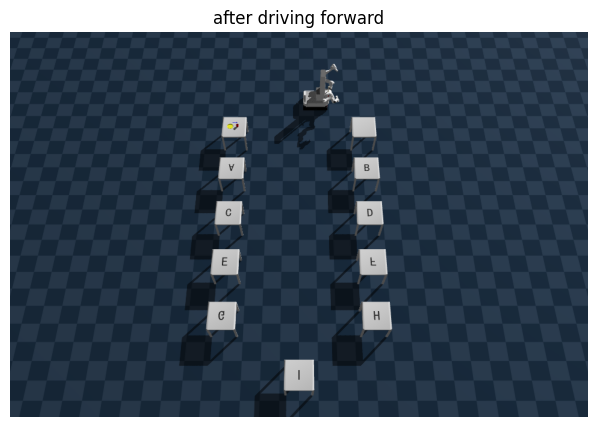

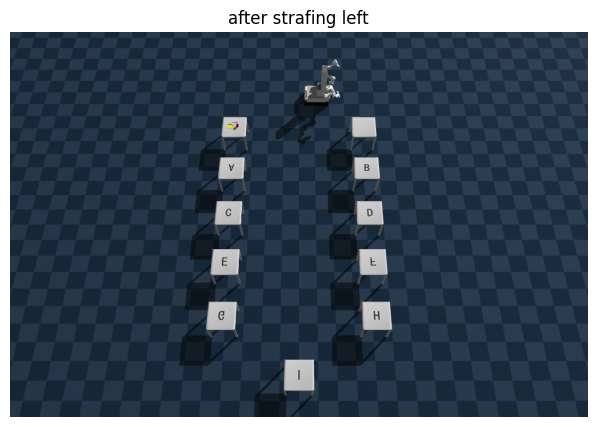

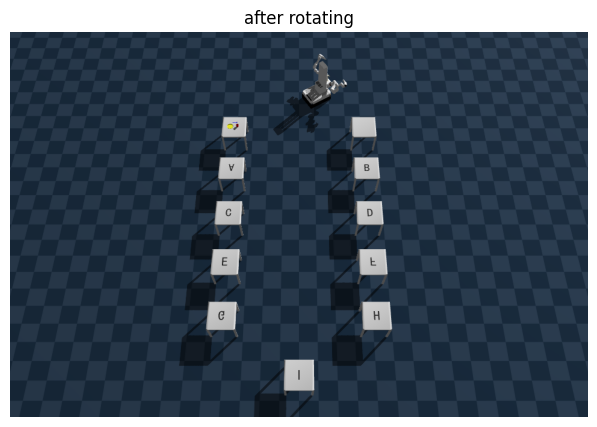

end base pose: [ 0.583  4.729 -0.   ] yaw(deg): 32.0


In [2]:
print("start base pose:", np.round(sim.get_base_pose()[0], 3))

sim.drive(0.5, 0.0, 0.0, steps=250)   # forward
show("after driving forward")

sim.drive(0.0, 0.5, 0.0, steps=150)   # strafe left
show("after strafing left")

sim.drive(0.0, 0.0, 1.2, steps=120)   # rotate in place (left)
sim.stop(steps=20)
show("after rotating")

pos, yaw = sim.get_base_pose()
print("end base pose:", np.round(pos, 3), "yaw(deg):", round(np.degrees(yaw), 1))

## 3. Control individual joints

Each arm has 7 joints and a 2-finger gripper. Set position targets directly:
* `sim.set_arm(side, q)` — 7 joint angles (rad) for `side` in `'left'` / `'right'`
* `sim.set_gripper(side, opening)` — finger opening in meters (`0.0` closed .. `0.04` open)

Targets are held every simulation step; pass `step=True, steps=N` to advance immediately.

left arm q (rad): [-0.   -1.51  0.   -2.2   0.    1.5   0.79]


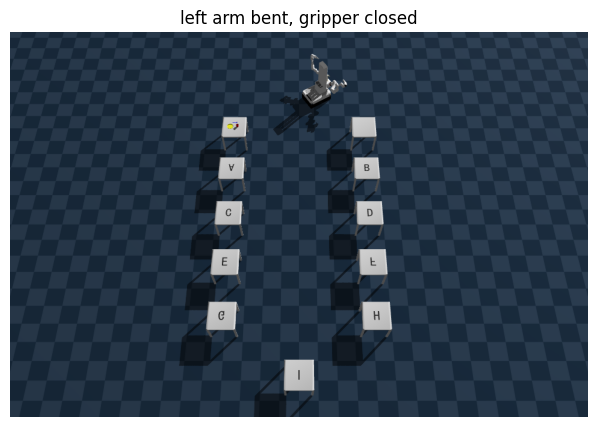

In [3]:
# Read the current left-arm joint angles, then bend joint 4 (elbow) and joint 6 (wrist).
q_left = sim.get_arm("left").copy()
print("left arm q (rad):", np.round(q_left, 2))

q_left[3] += 0.6    # joint4
q_left[5] -= 0.5    # joint6
sim.set_arm("left", q_left, step=True, steps=120)

# Close then open the left gripper.
sim.set_gripper("left", 0.0, step=True, steps=80)    # close
show("left arm bent, gripper closed")
sim.set_gripper("left", 0.04, step=True, steps=80)   # open again

## 4. Move the end-effectors with IK

`sim.move_ee(side, pos, quat=DOWN, n_waypoints, settle)` solves inverse kinematics for
one arm and moves its **finger tool-center-point (TCP)** to a world-frame `pos` along an
interpolated straight line. `quat` is the gripper orientation (default: pointing down).

We pick targets **relative to each arm's current TCP** so they are reachable. Use
`sim.get_ee_pos(side)` to read the current TCP, and `sim.ik(side, pos)` if you just want
the joint angles without moving.

left: TCP [0.464 5.663 0.83 ] -> target [0.544 5.663 0.71 ]
   IK q (rad): [-0.12 -1.77  0.03 -2.1   1.64  0.86  1.37]
   reached [0.525 5.665 0.732]  err=0.030 m


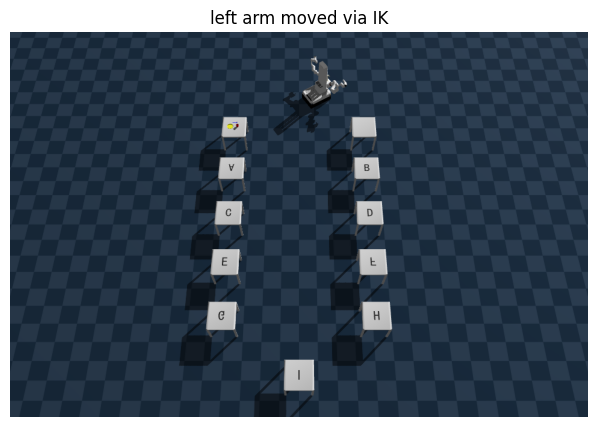

right: TCP [1.466 4.447 0.846] -> target [1.546 4.447 0.726]
   IK q (rad): [-0.24 -1.4  -0.26 -2.22 -1.23  1.33  0.15]
   reached [1.529 4.446 0.751]  err=0.030 m


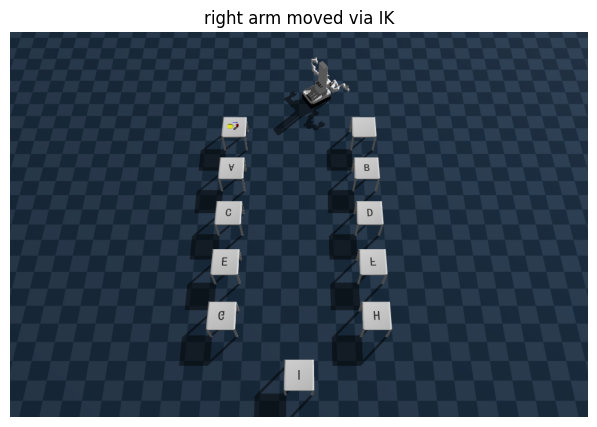

In [4]:
for side in ("left", "right"):
    tcp = sim.get_ee_pos(side)
    target = tcp + np.array([0.08, 0.0, -0.12])   # 8 cm forward, 12 cm down
    print(f"{side}: TCP {np.round(tcp, 3)} -> target {np.round(target, 3)}")

    q = sim.ik(side, tuple(target))               # IK solution (7 joint angles)
    print(f"   IK q (rad): {np.round(q, 2)}")

    sim.move_ee(side, tuple(target), n_waypoints=40)
    reached = sim.get_ee_pos(side)
    print(f"   reached {np.round(reached, 3)}  err={np.linalg.norm(reached - target):.3f} m")
    show(f"{side} arm moved via IK")

## 5. Save and embed the recorded video

Everything above was recorded (we called `start_recording()` in step 1). Write it to an
mp4 and embed it inline — the second way to visualize the run.

In [5]:
from IPython.display import Video

path = sim.save_video("videos/robot_scene_demo.mp4")
Video(path, embed=True, width=720)

✓ Saved video to videos/robot_scene_demo.mp4
